# Enviroment Setup

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Results'

# Results Load

In [26]:
baseline_df = pd.read_csv(os.path.join(RES_DIR, 'baseline_results.csv'))
sarima_df = pd.read_csv(os.path.join(RES_DIR, 'sarima_results.csv'))
xgb_df = pd.read_csv(os.path.join(RES_DIR, 'xgboost_results.csv'))
lstm_df = pd.read_csv(os.path.join(RES_DIR, 'lstm_results.csv'))
rf_df = pd.read_csv(os.path.join(RES_DIR, 'rf_results.csv'))
prophet_df = pd.read_csv(os.path.join(RES_DIR, 'prophet_results.csv'))

baseline_df['model'] = 'BASELINE'
sarima_df['model'] = 'SARIMA'
xgb_df['model'] = 'XGBoost'
lstm_df['model'] = 'LSTM'
rf_df['model'] = 'RF'
prophet_df['model'] = 'Prophet'

all_results = pd.concat([baseline_df, sarima_df, xgb_df, lstm_df, rf_df, prophet_df], ignore_index=True)

print(f"Loaded results: {len(baseline_df)} BASELINE + {len(sarima_df)} SARIMA + {len(xgb_df)} XGBoost + {len(lstm_df)} LSTM + {len(rf_df)} RF + {len(prophet_df)} Prophet")
print(f"Total: {len(all_results)} entries")

Loaded results: 6 BASELINE + 6 SARIMA + 6 XGBoost + 6 LSTM + 6 RF + 6 Prophet
Total: 36 entries


# Results Comparison

## Result Table

In [27]:
print("\n" + "=" * 100)
print("COMPLETE MODEL COMPARISON — ALL DATASETS")
print("=" * 100)

# pivot table
for metric in ['mae', 'rmse', 'smape']:
    print(f"\n--- {metric.upper()} ---")
    pivot = all_results.pivot(index='dataset', columns='model', values=metric)
    pivot = pivot[['BASELINE', 'SARIMA', 'XGBoost', 'LSTM', 'RF', 'Prophet']]

    pivot['Best'] = pivot.idxmin(axis=1)

    print(pivot.to_string())


COMPLETE MODEL COMPARISON — ALL DATASETS

--- MAE ---
model                         BASELINE  SARIMA  XGBoost    LSTM      RF  Prophet     Best
dataset                                                                                  
Austin TX (USA)                 826.42  176.31   145.84  176.87  124.97   158.95       RF
Ballarat (Australia)             34.14   15.03     6.82   10.20    7.01     8.73  XGBoost
Boralesgamuwa UC (Sri Lanka)      7.69    7.61     7.04    7.21    6.37     6.78       RF
Dehiwala MC (Sri Lanka)          33.06   36.21    30.00   36.29   28.32    30.32       RF
Homagama PS (Sri Lanka)          11.21   10.96    11.94   11.02   11.11    10.85  Prophet
Moratuwa MC (Sri Lanka)          17.60   17.06    18.74   16.71   16.97    17.83     LSTM

--- RMSE ---
model                         BASELINE  SARIMA  XGBoost    LSTM      RF  Prophet     Best
dataset                                                                                  
Austin TX (USA)                

## Model Statistics

In [28]:
print("\n" + "=" * 100)
print("AVERAGE METRICS PER MODEL")
print("=" * 100)

summary = all_results.groupby('model')[['mae', 'rmse', 'smape']].mean()
summary = summary.loc[['BASELINE' ,'SARIMA', 'XGBoost', 'LSTM', 'RF', 'Prophet']]

print(f"\n{'Model':<12s} | {'Avg MAE (t)':>12s} | {'Avg RMSE (t)':>13s} | {'Avg sMAPE (%)':>13s}")
print("-" * 60)
for model, row in summary.iterrows():
    print(f"{model:<12s} | {row['mae']:>12.2f} | {row['rmse']:>13.2f} | {row['smape']:>12.2f}%")

best_model = summary['mae'].idxmin()
print(f"\nBest model by average MAE:  {best_model}")
best_model = summary['rmse'].idxmin()
print(f"Best model by average RMSE: {best_model}")
best_model = summary['smape'].idxmin()
print(f"Best model by average sMAPE: {best_model}")


AVERAGE METRICS PER MODEL

Model        |  Avg MAE (t) |  Avg RMSE (t) | Avg sMAPE (%)
------------------------------------------------------------
BASELINE     |       155.02 |        181.37 |        45.58%
SARIMA       |        43.86 |         68.33 |        37.62%
XGBoost      |        36.73 |         57.45 |        33.72%
LSTM         |        43.05 |         60.38 |        34.51%
RF           |        32.46 |         52.55 |        30.67%
Prophet      |        38.91 |         56.47 |        37.63%

Best model by average MAE:  RF
Best model by average RMSE: RF
Best model by average sMAPE: RF


## MAE Comparison

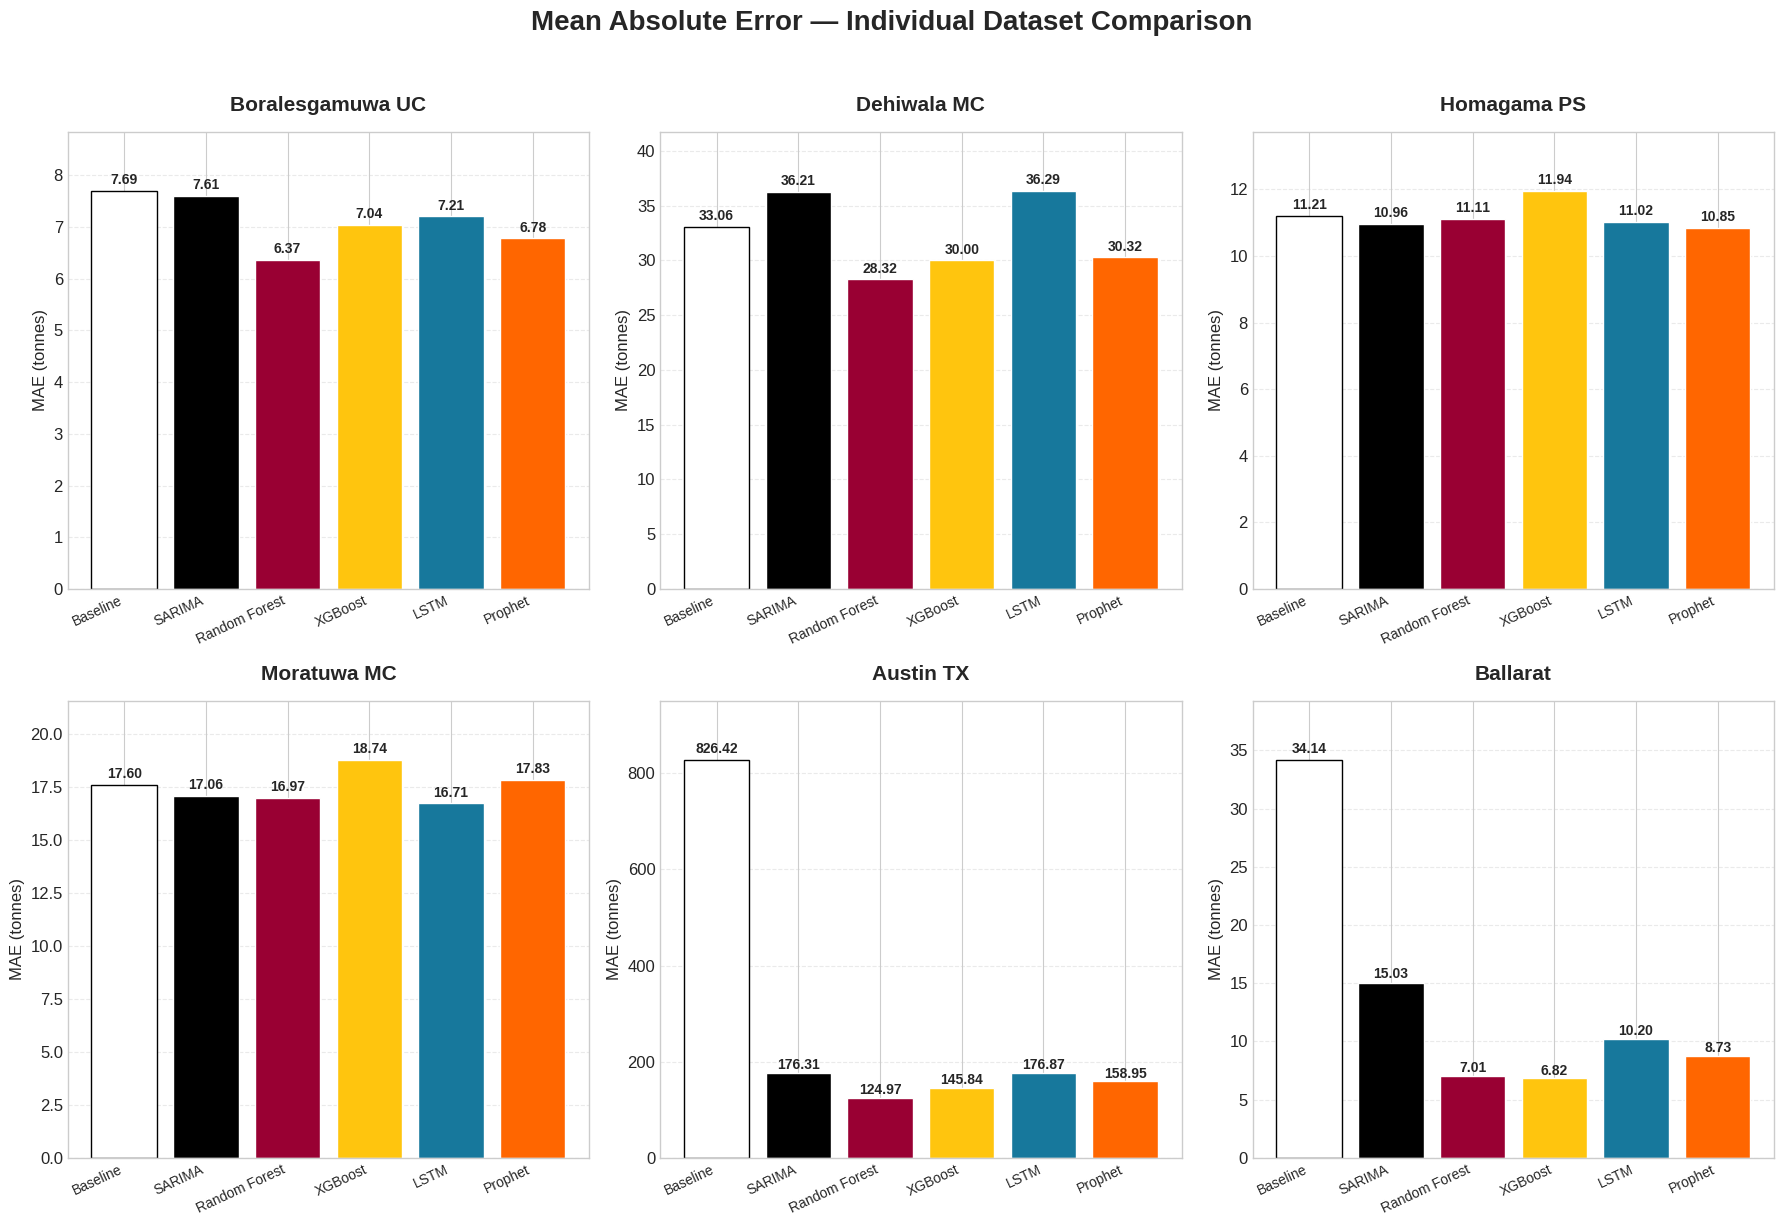

In [29]:
# --- Plot MAE Comparison ---

models = ['Baseline', 'SARIMA', 'Random Forest', 'XGBoost', 'LSTM', 'Prophet']
dataframes = [baseline_df, sarima_df, rf_df, xgb_df, lstm_df, prophet_df]
colors = ['#FFFFFF', '#000000', '#990033', '#FFC50E', '#17789C', '#FF6600']
edge_colors = ['black', 'white', 'white', 'white', 'white', 'white']

datasets = sarima_df['dataset'].values
short_names = [d.split('(')[0].strip() for d in datasets]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Premena na 1D pole pre jednoduchú iteráciu

for i, dataset_name in enumerate(datasets):
    ax = axes[i]

    # Extrakcia MAE hodnôt pre daný dataset zo všetkých DF
    mae_values = [df[df['dataset'] == dataset_name]['mae'].values[0] for df in dataframes]

    x_pos = np.arange(len(models))
    bars = ax.bar(x_pos, mae_values, color=colors, edgecolor=edge_colors, linewidth=1)

    # Individuálne nastavenia pre každý graf
    ax.set_title(short_names[i], fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('MAE (tonnes)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Automatická škála s hornou rezervou 15% pre popisky
    ax.set_ylim(0, max(mae_values) * 1.15)

    # Pridanie číselných hodnôt nad stĺpce
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Mean Absolute Error — Individual Dataset Comparison', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_mae_all.png'), dpi=150, bbox_inches='tight')
plt.show()

## RMSE Comparison

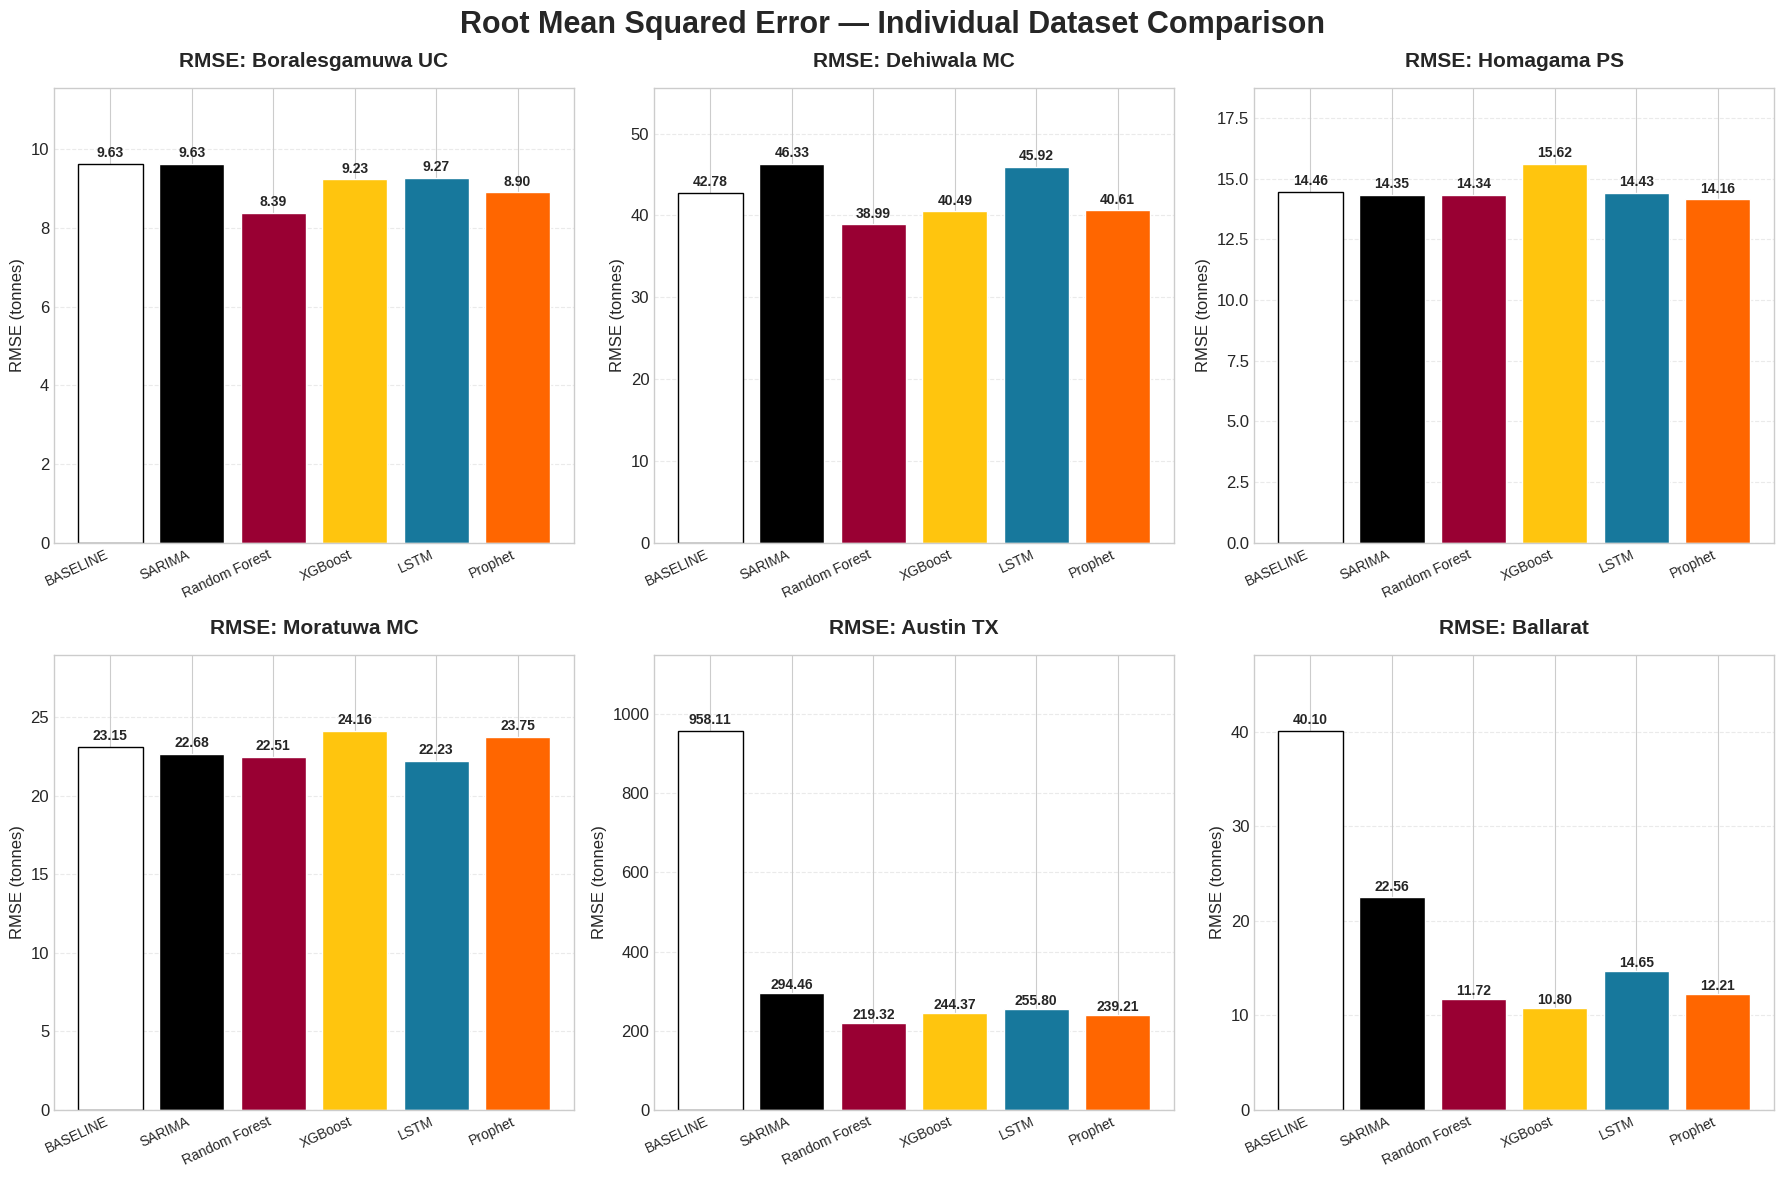

In [30]:
# --- Plot RMSE Comparison ---
models = ['BASELINE', 'SARIMA', 'Random Forest', 'XGBoost', 'LSTM', 'Prophet']
dataframes = [baseline_df, sarima_df, rf_df, xgb_df, lstm_df, prophet_df]
colors = ['#FFFFFF', '#000000', '#990033', '#FFC50E', '#17789C', '#FF6600']
edge_colors = ['black', 'white', 'white', 'white', 'white', 'white']

datasets = sarima_df['dataset'].values
short_names = [d.split('(')[0].strip() for d in datasets]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, dataset_name in enumerate(datasets):
    ax = axes[i]

    rmse_values = [df[df['dataset'] == dataset_name]['rmse'].values[0] for df in dataframes]
    x_pos = np.arange(len(models))
    bars = ax.bar(x_pos, rmse_values, color=colors, edgecolor=edge_colors, linewidth=1)

    ax.set_title(f'RMSE: {short_names[i]}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('RMSE (tonnes)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, max(rmse_values) * 1.2)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Root Mean Squared Error — Individual Dataset Comparison', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_rmse_all.png'), dpi=150, bbox_inches='tight')
plt.show()

## sMAPE Comparison

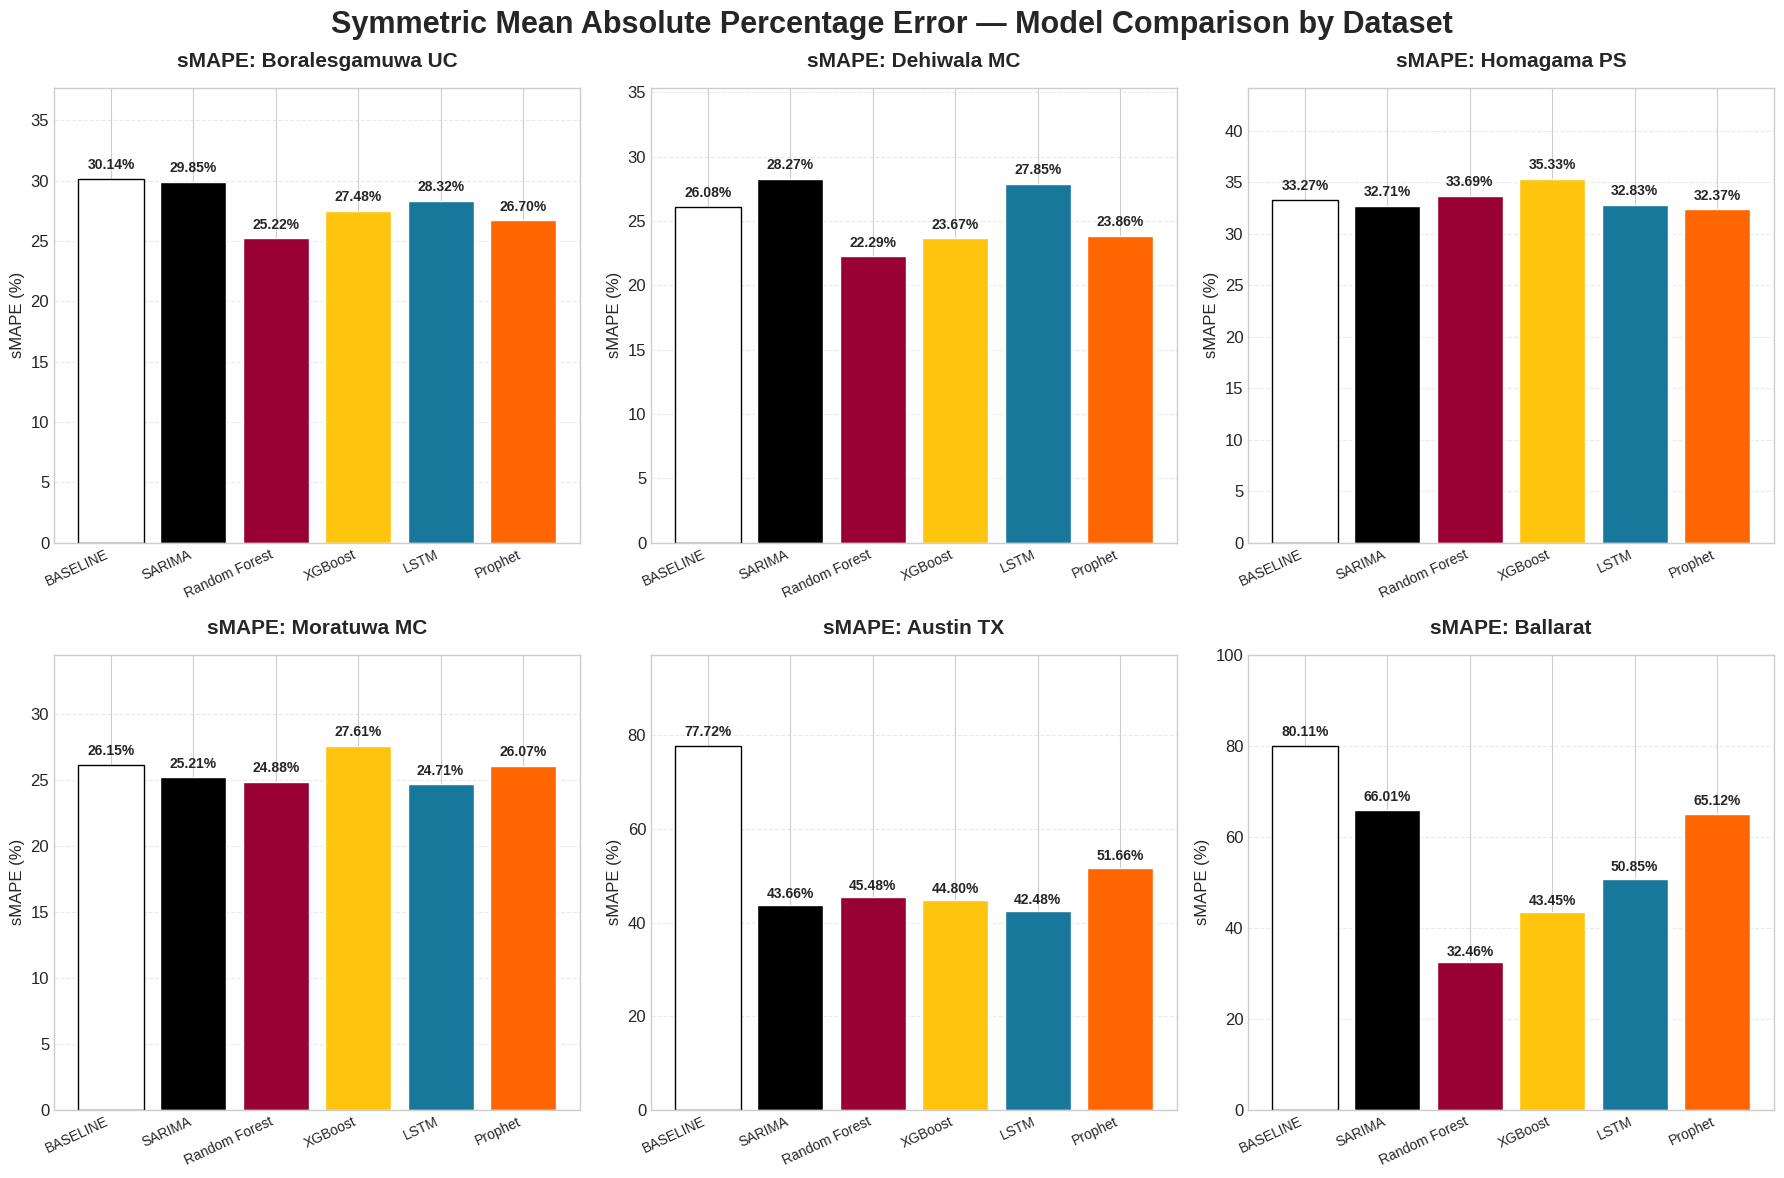

In [31]:
# --- Plot sMAPE Comparison ---
models = ['BASELINE', 'SARIMA', 'Random Forest', 'XGBoost', 'LSTM', 'Prophet']
dataframes = [baseline_df, sarima_df, rf_df, xgb_df, lstm_df, prophet_df]
colors = ['#FFFFFF', '#000000', '#990033', '#FFC50E', '#17789C', '#FF6600']
edge_colors = ['black', 'white', 'white', 'white', 'white', 'white']

datasets = sarima_df['dataset'].values
short_names = [d.split('(')[0].strip() for d in datasets]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, dataset_name in enumerate(datasets):
    ax = axes[i]

    smape_values = [df[df['dataset'] == dataset_name]['smape'].values[0] for df in dataframes]
    x_pos = np.arange(len(models))
    bars = ax.bar(x_pos, smape_values, color=colors, edgecolor=edge_colors, linewidth=1)

    ax.set_title(f'sMAPE: {short_names[i]}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('sMAPE (%)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, max(smape_values) * 1.25)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Symmetric Mean Absolute Percentage Error — Model Comparison by Dataset', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_mape_all.png'), dpi=150, bbox_inches='tight')
plt.show()

# Models improvement over BASELINE (MAE)


IMPROVEMENT OVER BASELINE (MAE)

Dataset                        | SARIMA vs BASELINE |  RF vs BASELINE | XGB vs BASELINE | LSTM vs BASELINE | Prophet vs BASELINE
--------------------------------------------------------------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |              +1.0% |          +17.2% |           +8.5% |            +6.2% |              +11.8%
Dehiwala MC (Sri Lanka)        |              -9.5% |          +14.3% |           +9.3% |            -9.8% |               +8.3%
Homagama PS (Sri Lanka)        |              +2.2% |           +0.9% |           -6.5% |            +1.7% |               +3.2%
Moratuwa MC (Sri Lanka)        |              +3.1% |           +3.6% |           -6.5% |            +5.1% |               -1.3%
Austin TX (USA)                |             +78.7% |          +84.9% |          +82.4% |           +78.6% |              +80.8%
Ballarat (Australia)           |             +56.0% |          

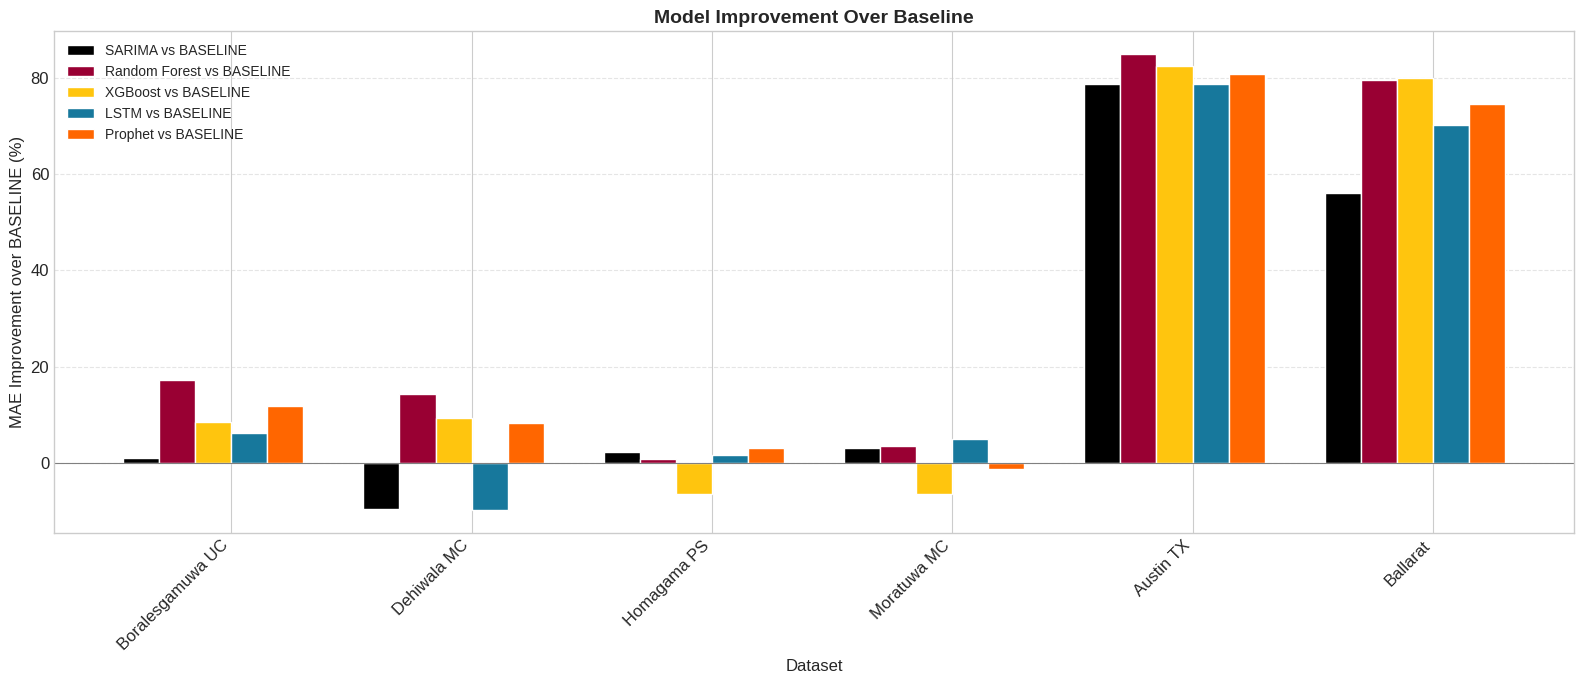

In [32]:
print("\n" + "=" * 128)
print("IMPROVEMENT OVER BASELINE (MAE)")
print("=" * 128)

comparison = baseline_df[['dataset', 'mae']].rename(columns={'mae': 'baseline_mae'})
comparison = comparison.merge(sarima_df[['dataset', 'mae']].rename(columns={'mae': 'sarima_mae'}), on='dataset')
comparison = comparison.merge(rf_df[['dataset', 'mae']].rename(columns={'mae': 'rf_mae'}), on='dataset')
comparison = comparison.merge(xgb_df[['dataset', 'mae']].rename(columns={'mae': 'xgb_mae'}), on='dataset')
comparison = comparison.merge(lstm_df[['dataset', 'mae']].rename(columns={'mae': 'lstm_mae'}), on='dataset')
comparison = comparison.merge(prophet_df[['dataset', 'mae']].rename(columns={'mae': 'prophet_mae'}), on='dataset')

comparison['sarima_improvement'] = (comparison['baseline_mae'] - comparison['sarima_mae']) / comparison['baseline_mae'] * 100
comparison['rf_improvement'] = (comparison['baseline_mae'] - comparison['rf_mae']) / comparison['baseline_mae'] * 100
comparison['xgb_improvement'] = (comparison['baseline_mae'] - comparison['xgb_mae']) / comparison['baseline_mae'] * 100
comparison['lstm_improvement'] = (comparison['baseline_mae'] - comparison['lstm_mae']) / comparison['baseline_mae'] * 100
comparison['prophet_improvement'] = (comparison['baseline_mae'] - comparison['prophet_mae']) / comparison['baseline_mae'] * 100

print(f"\n{'Dataset':<30s} | {'SARIMA vs BASELINE':>18s} | {'RF vs BASELINE':>15s} | {'XGB vs BASELINE':>15s} | {'LSTM vs BASELINE':>16s} | {'Prophet vs BASELINE':>19s}")
print("-" * 128)

for _, row in comparison.iterrows():
    print(f"{row['dataset']:<30s} | {row['sarima_improvement']:>+17.1f}% | {row['rf_improvement']:>+14.1f}% | {row['xgb_improvement']:>+14.1f}% | {row['lstm_improvement']:>+15.1f}% | {row['prophet_improvement']:>+18.1f}%")

print("-" * 128)
avg_sarima = comparison['sarima_improvement'].mean()
avg_rf = comparison['rf_improvement'].mean()
avg_xgb = comparison['xgb_improvement'].mean()
avg_lstm = comparison['lstm_improvement'].mean()
avg_prophet = comparison['prophet_improvement'].mean()

print(f"{'AVERAGE':<30s} | {avg_sarima:>+17.1f}% | {avg_rf:>+14.1f}% | {avg_xgb:>+14.1f}% | {avg_lstm:>+15.1f}% | {avg_prophet:>+18.1f}%")

# --- Plot: Improvement over Baseline ---
fig, ax = plt.subplots(figsize=(16, 7))

short_names = [d.split('(')[0].strip() for d in comparison['dataset']]
x = np.arange(len(comparison))
width = 0.15

ax.bar(x - 2.5*width, comparison['sarima_improvement'], width, label='SARIMA vs BASELINE', color='#000000', edgecolor='white')
ax.bar(x - 1.5*width, comparison['rf_improvement'], width, label='Random Forest vs BASELINE', color='#990033', edgecolor='white')
ax.bar(x - 0.5*width, comparison['xgb_improvement'], width, label='XGBoost vs BASELINE', color='#FFC50E', edgecolor='white')
ax.bar(x + 0.5*width, comparison['lstm_improvement'], width, label='LSTM vs BASELINE', color='#17789C', edgecolor='white')
ax.bar(x + 1.5*width, comparison['prophet_improvement'], width, label='Prophet vs BASELINE', color='#FF6600', edgecolor='white')

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_xlabel('Dataset')
ax.set_ylabel('MAE Improvement over BASELINE (%)')
ax.set_title('Model Improvement Over Baseline', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_improvement_over_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

# Satistical Significance of Models - Wilcoxon Signed-Rank Test

In [33]:
from scipy.stats import wilcoxon

print("\n" + "=" * 100)
print("STATISTICAL SIGNIFICANCE — Wilcoxon Signed-Rank Test")
print("=" * 100)
print("\nTests whether MAE differences between model pairs are statistically significant.")
print("p < 0.05 = significant difference, p >= 0.05 = no significant difference.\n")

models = ['BASELINE', 'SARIMA', 'RF', 'XGBoost', 'LSTM', 'Prophet']
mae_pivot = all_results.pivot(index='dataset', columns='model', values='mae')


pairs_to_test = []
for i in range(len(models)):
    for j in range(i+1, len(models)):
        pairs_to_test.append((models[i], models[j]))

print(f"{'Model A':<12s} vs {'Model B':<12s} | {'Stat':>8s} | {'p-value':>8s} | {'Significant?':>14s} | {'Better':>12s}")
print("-" * 80)

significance_results = []
for model_a, model_b in pairs_to_test:
    if model_a not in mae_pivot.columns or model_b not in mae_pivot.columns:
        continue

    a_vals = mae_pivot[model_a].values
    b_vals = mae_pivot[model_b].values


    try:
        stat, p_value = wilcoxon(a_vals, b_vals)
        significant = "YES" if p_value < 0.05 else "NO"
        better = model_a if np.mean(a_vals) < np.mean(b_vals) else model_b

        print(f"{model_a:<12s} vs {model_b:<12s} | {stat:>8.1f} | {p_value:>8.4f} | {significant:>14s} | {better:>12s}")

        significance_results.append({
            'model_a': model_a,
            'model_b': model_b,
            'statistic': round(stat, 4),
            'p_value': round(p_value, 4),
            'significant': significant,
            'better_model': better
        })
    except Exception as e:
        print(f"{model_a:<12s} vs {model_b:<12s} | {'N/A':>8s} | {'N/A':>8s} | {'INSUFFICIENT':>14s} |")

sig_df = pd.DataFrame(significance_results)
sig_df.to_csv(os.path.join(RES_DIR, 'wilcoxon_significance.csv'), index=False)
print(f"\nSignificance results saved to: {RES_DIR}/wilcoxon_significance.csv")


STATISTICAL SIGNIFICANCE — Wilcoxon Signed-Rank Test

Tests whether MAE differences between model pairs are statistically significant.
p < 0.05 = significant difference, p >= 0.05 = no significant difference.

Model A      vs Model B      |     Stat |  p-value |   Significant? |       Better
--------------------------------------------------------------------------------
BASELINE     vs SARIMA       |      4.0 |   0.2188 |             NO |       SARIMA
BASELINE     vs RF           |      0.0 |   0.0312 |            YES |           RF
BASELINE     vs XGBoost      |      5.0 |   0.3125 |             NO |      XGBoost
BASELINE     vs LSTM         |      4.0 |   0.2188 |             NO |         LSTM
BASELINE     vs Prophet      |      1.0 |   0.0625 |             NO |      Prophet
SARIMA       vs RF           |      2.0 |   0.0938 |             NO |           RF
SARIMA       vs XGBoost      |      5.0 |   0.3125 |             NO |      XGBoost
SARIMA       vs LSTM         |      8.0 |   

# Final Model Ranking

In [34]:
print("\n" + "=" * 100)
print("FINAL MODEL RANKING")
print("=" * 100)

# wins on ds per model
mae_pivot = all_results.pivot(index='dataset', columns='model', values='mae')
wins = mae_pivot.idxmin(axis=1).value_counts()

print("\nDataset wins (lowest MAE):")
for model, count in wins.items():
    print(f"  {model}: {count}/{len(mae_pivot)} datasets")

print(f"""
SUMMARY:
  - Best overall model:      {summary['mae'].idxmin()} (lowest average MAE: {summary['mae'].min():.2f}t)
  - Best individual result:  {all_results.loc[all_results['mae'].idxmin(), 'model']} on {all_results.loc[all_results['mae'].idxmin(), 'dataset']} (MAE: {all_results['mae'].min():.2f}t)
  - Baseline avg MAE:        {summary.loc['BASELINE', 'mae']:.2f}t
  - SARIMA avg improvement:  {avg_sarima:+.1f}% over BASELINE
  - RF avg improvement:      {avg_rf:+.1f}% over BASELINE
  - XGBoost avg improvement: {avg_xgb:+.1f}% over BASELINE
  - LSTM avg improvement:    {avg_lstm:+.1f}% over BASELINE
  - Prophet avg improvement: {avg_prophet:+.1f}% over BASELINE

MODEL RANKING (by average MAE):
  1. {summary['mae'].sort_values().index[0]:<20s} {summary['mae'].sort_values().values[0]:.2f}t
  2. {summary['mae'].sort_values().index[1]:<20s} {summary['mae'].sort_values().values[1]:.2f}t
  3. {summary['mae'].sort_values().index[2]:<20s} {summary['mae'].sort_values().values[2]:.2f}t
  4. {summary['mae'].sort_values().index[3]:<20s} {summary['mae'].sort_values().values[3]:.2f}t
  5. {summary['mae'].sort_values().index[4]:<20s} {summary['mae'].sort_values().values[4]:.2f}t
  6. {summary['mae'].sort_values().index[5]:<20s} {summary['mae'].sort_values().values[5]:.2f}t

STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank Test, alpha=0.05):
  - Only Baseline vs RF showed statistically significant difference (p=0.031).
  - Differences between other model pairs were not statistically significant
    at the 0.05 level, likely due to the small number of datasets (n=6).
  - Several pairs (SARIMA vs RF, SARIMA vs Prophet, RF vs XGBoost,
    RF vs Prophet) approached significance (p=0.06-0.09).

CONCLUSION:
  Random Forest achieved the lowest average MAE ({summary.loc['RF','mae']:.2f}t) and
  sMAPE ({summary.loc['RF','smape']:.2f}%), winning on 4 out of 6 datasets without
  any hyperparameter optimization. This was the only model to show
  a statistically significant improvement over the baseline (p=0.031).

  XGBoost performed comparably to RF (avg MAE {summary.loc['XGBoost','mae']:.2f}t),
  winning on the remaining 2 datasets. The difference between RF and
  XGBoost was not statistically significant (p=0.063), suggesting both
  tree-based ensemble approaches are equally effective for this task.

  SARIMA and Prophet showed moderate improvement over baseline but
  without statistical significance. LSTM performed comparably to
  Prophet, with both models outperforming baseline on most datasets
  but failing to match tree-based models consistently.

  The limited statistical significance across most pairs is attributable
  to the small sample size (6 datasets). Despite this, the consistent
  pattern of tree-based models outperforming alternatives across
  diverse datasets provides practical evidence of their suitability
  for daily municipal waste prediction.

  These results suggest that well-crafted feature engineering (lag
  values, rolling statistics, calendar and holiday data) combined with
  tree-based ensemble models provides the most effective approach,
  outperforming both classical time series methods and deep learning
  approaches on datasets of this scale.
""")

# save results
all_results.to_csv(os.path.join(RES_DIR, 'all_models_comparison.csv'), index=False)
comparison.to_csv(os.path.join(RES_DIR, 'improvement_over_baseline.csv'), index=False)
print(f"\nAll results saved to {RES_DIR}")


FINAL MODEL RANKING

Dataset wins (lowest MAE):
  RF: 3/6 datasets
  XGBoost: 1/6 datasets
  Prophet: 1/6 datasets
  LSTM: 1/6 datasets

SUMMARY:
  - Best overall model:      RF (lowest average MAE: 32.46t)
  - Best individual result:  RF on Boralesgamuwa UC (Sri Lanka) (MAE: 6.37t)
  - Baseline avg MAE:        155.02t
  - SARIMA avg improvement:  +21.9% over BASELINE
  - RF avg improvement:      +33.4% over BASELINE
  - XGBoost avg improvement: +27.8% over BASELINE
  - LSTM avg improvement:    +25.3% over BASELINE
  - Prophet avg improvement: +29.5% over BASELINE

MODEL RANKING (by average MAE):
  1. RF                   32.46t
  2. XGBoost              36.73t
  3. Prophet              38.91t
  4. LSTM                 43.05t
  5. SARIMA               43.86t
  6. BASELINE             155.02t

STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank Test, alpha=0.05):
  - Only Baseline vs RF showed statistically significant difference (p=0.031).
  - Differences between other model pairs were not